# 検証：疾患の創薬標的としての妥当性を Yes / No で判定する

**どの病気にも使える共通プロンプト**で、遺伝子リストの各遺伝子について
「この遺伝子を活性化または抑制することで、その病気や症状が改善する可能性があるか？」を AI に Yes / No で答えさせ、
**Yes の確率**を集めます。正解遺伝子（承認薬の標的）が上位に来るかを、ランダム遺伝子と比べて評価します。

## このノートの方針
- 外部の .py は参照しません。処理はセル内に書き、`def` は AI 役と UniProt 照会など、何度も呼ぶものだけに限ります（各 def の前に説明があります）。
- 変数は **設定セル** にまとめてあります：病名、病気の情報（箇条書き最大5個。**治したい症状と、それに関わる臓器・細胞・機能**。分子名・原因遺伝子名は書かない）、回答回数、遺伝子リストのファイル、モデルの場所。
- Yes 確率は2通りで出せます。
  - **確率読み（logprob）**：次のトークンの確率から Yes / No を読む（guidance の `select` ＋ 制約前 top_k）。選択肢の順を入れ替えて2回読み、平均。
  - **サンプリング（sample）**：温度を付けて `N_ANSWERS` 回答えさせ、Yes の割合を取る。
  - 統計的には、サンプリングの Yes 割合は確率読みの値のまわりでばらつく推定値です（回数を増やすほど近づきます）。両方出して比べられます。
- モデルは **`~/llm/models` の GGUF（guidance + llama.cpp）** と **Ollama** のどちらでも使えます。設定セルで一覧から選びます。
- モデルが無い環境では **モック**（擬似乱数）で動きます。その場合は出力に警告が出ます。数値に意味はありません。

## プロンプトに入れる遺伝子名
遺伝子記号だけでなく **タンパク質名** も入れます（例: `TNF (tumor necrosis factor)`）。
タンパク質名は UniProt から取得し（届かない環境ではキャッシュ → HGNC の遺伝子名の順に代用）、どこから来たかを列に残します。

### このセルがすること：準備
- 標準ライブラリと pandas / matplotlib を読み込みます。

In [1]:
import os, re, csv, math, glob, json, time, random, hashlib, urllib.request, urllib.parse
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 80)
ROOT = os.path.abspath("..")          # notebooks/ から実行する前提。1つ上がリポジトリ直下
print("ready:", ROOT)

ready: /home/user/gene_disease_prediction02


## 設定（ここだけ変えれば別の病気・別のリストで使える）

### このセルがすること：変数をまとめて宣言する
- `DISEASE`：病名（英語）。`DISEASE_INFO`：病気の情報の箇条書き、**最大5個**（多い分は切り捨てます）。
- **`DISEASE_INFO` の書き方のルール**
  1. 「治したい症状」を主語にし、「その症状が、どの臓器・どの細胞の、どんな機能の異常と関係するか」を書く。
  2. **分子名（サイトカイン名、受容体名、神経伝達物質名など）と、原因遺伝子名は書かない。** 書くと、その分子の遺伝子が質問の答えに漏れて、AI の知識ではなくプロンプトで順位が決まってしまう。
  3. 次のセルで、箇条書きに遺伝子記号・遺伝子名が混ざっていないかを HGNC の一覧で自動点検する。
- `GENE_FILE`：調べる遺伝子リスト（TSV）。`symbol` 列が必須。`protein_name_uniprot` `gene_name` `uniprot_ids` `category` `label` 列があれば使います。
- `N_ANSWERS`：サンプリングで答えさせる回数。`TEMPERATURE`：その温度。`MODE`：`"logprob"` / `"sample"` / `"both"`。
- `MAX_GENES`：試しに少数で回すときの上限（None なら全部）。
- **モデルの選択**：`~/llm/models` の GGUF と、起動中の Ollama のモデルを一覧にして選びます。`BACKEND`（auto / gguf / ollama / mock）と `MODEL_SELECT`（auto / 番号 / 名前の一部）で指定。auto なら txgemma → medgemma → gemma の順で優先。どれも無ければモック。

In [2]:
# --- 病気 ---
DISEASE = "rheumatoid arthritis"
DISEASE_INFO = [                                   # 最大5個。「治したい症状 → 関わる臓器・細胞・機能」。分子名・原因遺伝子名は書かない
    "Joint pain, swelling and morning stiffness, symmetric in the small joints of hands and feet: caused by chronic inflammation of the synovial membrane that lines the joints",
    "Progressive joint deformity and loss of function: invasive growth of the synovial lining cells and excessive bone resorption by bone-degrading cells erode cartilage and bone",
    "The inflammation is sustained by the adaptive immune system: self-reactive T cells, antibody-producing B cells and infiltrating macrophages accumulate in the synovium",
    "Fatigue, low-grade fever and anaemia: systemic effects of inflammatory mediators released by the activated immune cells",
    "Accelerated cardiovascular disease and interstitial lung disease: consequences of long-standing systemic inflammation",
]
DISEASE_INFO = DISEASE_INFO[:5]

# --- 遺伝子リスト ---
GENE_FILE = os.path.join(ROOT, "data", "genes", "ra_set100.tsv")
MAX_GENES = None                                   # 例: 20 で試運転

# --- 回答方法 ---
MODE = "both"                                      # "logprob" / "sample" / "both"
N_ANSWERS = 5                                      # サンプリングの回答回数
TEMPERATURE = 0.7                                  # サンプリングの温度
TOP_K = 50                                         # 確率読みで記録する上位トークン数

# --- モデルの選択 ---
# BACKEND: "auto" = Ollama が起動していれば Ollama、無ければ ~/llm/models の GGUF、それも無ければモック
#          "gguf" / "ollama" / "mock" で固定もできる
BACKEND = "auto"
MODEL_DIR = os.path.expanduser("~/llm/models")            # GGUF の置き場所
OLLAMA_URL = "http://localhost:11434"                     # Ollama サーバー
MODEL_SELECT = "auto"                                     # "auto" / 一覧の番号（例 2）/ 名前の一部（例 "medgemma"）
PREFER = ("txgemma", "medgemma", "gemma")                 # auto のとき、この順で名前に含むものを優先
TOP_K = 50                                                # 確率読みで記録する上位トークン数

# 使えるモデルを集める（GGUF ファイルと Ollama のモデル）
models = []
for h in sorted(glob.glob(os.path.join(MODEL_DIR, "**", "*.gguf"), recursive=True)):
    models.append({"kind": "gguf", "name": os.path.basename(h), "path": h, "size_gb": round(os.path.getsize(h) / 1e9, 2)})
try:
    with urllib.request.urlopen(OLLAMA_URL + "/api/tags", timeout=3) as r:
        for m in json.load(r).get("models", []):
            models.append({"kind": "ollama", "name": m["name"], "path": m["name"], "size_gb": round(m.get("size", 0) / 1e9, 2)})
except Exception:
    pass                                                   # Ollama が起動していない

# 選ぶ
chosen = None
if BACKEND == "mock":
    pass
elif isinstance(MODEL_SELECT, int):
    chosen = models[MODEL_SELECT]
else:
    pool = [m for m in models if BACKEND == "auto" or m["kind"] == BACKEND]
    if MODEL_SELECT != "auto":
        pool = [m for m in pool if MODEL_SELECT.lower() in m["name"].lower()]
    ranked = sorted(pool, key=lambda m: (min([i for i, p in enumerate(PREFER) if p in m["name"].lower()] or [99]),
                                         0 if m["kind"] == "ollama" else 1, m["name"]))
    chosen = ranked[0] if ranked else None
USE_LLM = chosen is not None
BACKEND_USED = chosen["kind"] if chosen else "mock"
MODEL_PATH = chosen["path"] if chosen else None            # GGUF ならファイルパス、Ollama ならモデル名

print("使えるモデル:")
for i, m in enumerate(models): print(f"  [{i}] {m['kind']:6s} {m['size_gb']:6.2f} GB  {m['name']}")
print("選択:", f"{BACKEND_USED}: {MODEL_PATH}" if USE_LLM else "モック（擬似乱数。数値に意味なし）")

# --- 出力 ---
OUT_DIR = os.path.join(ROOT, "outputs"); os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, os.path.basename(GENE_FILE).replace(".tsv", "") + "_yesno.csv")

print("disease:", DISEASE, "| info bullets:", len(DISEASE_INFO))
print("gene file:", GENE_FILE)


使えるモデル:
選択: モック（擬似乱数。数値に意味なし）
disease: rheumatoid arthritis | info bullets: 5
gene file: /home/user/gene_disease_prediction02/data/genes/ra_set100.tsv


## 共通プロンプト

### このセルがすること：どの病気でも使う質問文の雛形を決め、例を表示し、漏れを点検する
- 変数は `{disease}`（病名）、`{info}`（症状と臓器・細胞・機能の箇条書き）、`{gene}`（記号＋タンパク質名）の3つだけです。
- 「活性化または抑制することで改善する可能性があるか」を1問で聞きます。向き（活性化か抑制か）は問いません。
- 選択肢の順（Yes or No / No or Yes）は `{options}` で入れ替えます。
- 最後に、箇条書きに HGNC の遺伝子記号・遺伝子名・代表的な分子名（神経伝達物質、サイトカイン等）が含まれていないかを点検し、あれば警告します（止めはしません）。

In [3]:
PROMPT_TEMPLATE = (
    "You are an expert in drug discovery and human disease biology.\n"
    "Disease: {disease}\n"
    "Target symptoms and the organ, cell and functional abnormalities behind them:\n{info}\n"
    "Gene: {gene}\n"
    "Question: Could activating or inhibiting this gene plausibly improve {disease} or its symptoms, "
    "i.e. is it a plausible drug target for {disease}?\n"
    "{options}\n"
    "Answer:"
)
OPTIONS = {"yes_first": "Answer with Yes or No.", "no_first": "Answer with No or Yes."}

def render_prompt(gene_label, order="yes_first"):
    info = "\n".join(f"- {b}" for b in DISEASE_INFO)
    return PROMPT_TEMPLATE.format(disease=DISEASE, info=info, gene=gene_label, options=OPTIONS[order])

print(render_prompt("TNF (tumor necrosis factor)"))

# --- 漏れの点検：箇条書きに遺伝子記号・遺伝子名・代表的な分子名が入っていないか ---
hgnc = pd.read_csv(os.path.join(ROOT, "data", "genes", "hgnc_protein_coding.tsv"), sep="\t", dtype=str).fillna("")
symbols = set(hgnc["symbol"])
long_names = {n.lower() for n in hgnc["gene_name"] if len(n) >= 10}          # 短い遺伝子名（例 "actin"）は誤検出が多いので除く
MOLECULE_WORDS = ["dopamine", "serotonin", "glutamate", "gaba", "acetylcholine", "noradrenaline", "histamine",
                  "interleukin", "interferon", "cytokine tnf", "tumor necrosis", "insulin", "cortisol", "estrogen", "testosterone"]
leaks = []
for b in DISEASE_INFO:
    for tok in re.findall(r"\b[A-Z][A-Z0-9]{1,9}(?:-[A-Z0-9]{1,5})?\b", b):
        if tok in symbols: leaks.append((tok, "HGNC symbol", b[:60]))
    low = b.lower()
    for n in long_names:
        if n in low: leaks.append((n, "HGNC gene name", b[:60]))
    for w in MOLECULE_WORDS:
        if w in low: leaks.append((w, "molecule word", b[:60]))
if leaks:
    print("\n[警告] 箇条書きに分子名・遺伝子名が含まれています。書き換えを検討してください:")
    for l in leaks: print("  -", l)
else:
    print("\n点検: 遺伝子記号・遺伝子名・代表的な分子名は含まれていません。")

You are an expert in drug discovery and human disease biology.
Disease: rheumatoid arthritis
Target symptoms and the organ, cell and functional abnormalities behind them:
- Joint pain, swelling and morning stiffness, symmetric in the small joints of hands and feet: caused by chronic inflammation of the synovial membrane that lines the joints
- Progressive joint deformity and loss of function: invasive growth of the synovial lining cells and excessive bone resorption by bone-degrading cells erode cartilage and bone
- The inflammation is sustained by the adaptive immune system: self-reactive T cells, antibody-producing B cells and infiltrating macrophages accumulate in the synovium
- Fatigue, low-grade fever and anaemia: systemic effects of inflammatory mediators released by the activated immune cells
- Accelerated cardiovascular disease and interstitial lung disease: consequences of long-standing systemic inflammation
Gene: TNF (tumor necrosis factor)
Question: Could activating or inhib


点検: 遺伝子記号・遺伝子名・代表的な分子名は含まれていません。


## 入力遺伝子

### このセルがすること：遺伝子リストを読み込む
- `symbol` 列が無ければ止まります。`category` / `label` が無ければ空欄にします（評価の一部が省略されます）。

In [4]:
genes = pd.read_csv(GENE_FILE, sep="\t", dtype=str).fillna("")
assert "symbol" in genes.columns, "symbol 列が必要です"
for col in ("protein_name_uniprot", "gene_name", "uniprot_ids", "category", "label"):
    if col not in genes.columns: genes[col] = ""
if MAX_GENES: genes = genes.head(MAX_GENES).copy()
print(len(genes), "genes")
genes[["symbol", "gene_name", "uniprot_ids", "protein_name_uniprot", "category", "label"]].head(8)

100 genes


,symbol,gene_name,uniprot_ids,protein_name_uniprot,category,label
0,PADI4,peptidyl arginine deiminase 4,Q9UM07,,candidate,0
1,CCL21,C-C motif chemokine ligand 21,O00585,,candidate,0
2,TNFRSF14,TNF receptor superfamily member 14,Q92956,,candidate,0
3,IL7R,interleukin 7 receptor,P16871,,candidate,0
4,IRF5,interferon regulatory factor 5,Q13568,,candidate,0
5,BTK,Bruton tyrosine kinase,Q06187,,candidate,0
6,CSF2,colony stimulating factor 2,P04141,,candidate,0
7,IL2RB,interleukin 2 receptor subunit beta,P14784,,candidate,0


## タンパク質名（UniProt）

### `uniprot_protein_names(accessions)` — UniProt からタンパク質名を取る
どんな def か：UniProt アクセッション（例 P01375）のリストを渡すと、推奨タンパク質名（例 "Tumor necrosis factor"）の辞書を返します。

各ステップ：
1. キャッシュ `data/genes/uniprot_names_cache.tsv` を読み、既にあるものは問い合わせません。
2. 残りを 100 件ずつ UniProt REST（`rest.uniprot.org`）に問い合わせます（形式: TSV、列: accession, protein_name）。
3. 取れた分をキャッシュに追記します。ネットワークに届かないときは例外を握りつぶして、取れた分だけ返します。

return：dict（accession → protein name）。取れなかったものは含まれません。

### このセルがすること：各遺伝子の「プロンプトに入れる名前」を決める
優先順位：① ファイルの `protein_name_uniprot` 列 → ② UniProt 照会（キャッシュ含む） → ③ HGNC の `gene_name` → ④ 記号のみ。
どれを使ったかを `name_source` 列に残します。

In [5]:
CACHE = os.path.join(ROOT, "data", "genes", "uniprot_names_cache.tsv")

def uniprot_protein_names(accessions):
    names = {}
    if os.path.exists(CACHE):                                                       # 1. キャッシュ
        for row in csv.DictReader(open(CACHE, encoding="utf-8"), delimiter="\t"):
            names[row["accession"]] = row["protein_name"]
    todo = sorted({a for a in accessions if a and a not in names})
    fetched = {}
    for i in range(0, len(todo), 100):                                             # 2. REST に 100 件ずつ
        chunk = todo[i:i + 100]
        url = "https://rest.uniprot.org/uniprotkb/search?" + urllib.parse.urlencode(
            {"query": " OR ".join(f"accession:{a}" for a in chunk), "fields": "accession,protein_name", "format": "tsv", "size": 500})
        try:
            with urllib.request.urlopen(url, timeout=60) as r:
                for line in r.read().decode().splitlines()[1:]:
                    acc, name = line.split("\t")[:2]
                    fetched[acc] = name
        except Exception as e:
            print(f"UniProt に届きません（{type(e).__name__}）。取れた分だけ使います。"); break
    if fetched:                                                                     # 3. キャッシュに追記
        new = not os.path.exists(CACHE)
        with open(CACHE, "a", encoding="utf-8", newline="") as f:
            w = csv.writer(f, delimiter="\t")
            if new: w.writerow(["accession", "protein_name"])
            for k, v in fetched.items(): w.writerow([k, v])
    names.update(fetched)
    return names

accs = [a for s in genes["uniprot_ids"] for a in s.split("|") if a]
uni = uniprot_protein_names(accs)

labels, sources = [], []
for _, g in genes.iterrows():
    first_acc = (g["uniprot_ids"].split("|") or [""])[0]
    if g["protein_name_uniprot"]:
        name, src = g["protein_name_uniprot"].split("|")[0], "file"
    elif first_acc in uni:
        name, src = uni[first_acc], "uniprot_rest"
    elif g["gene_name"]:
        name, src = g["gene_name"], "hgnc_gene_name"
    else:
        name, src = "", "symbol_only"
    labels.append(f"{g['symbol']} ({name})" if name else g["symbol"]); sources.append(src)
genes["gene_label"] = labels; genes["name_source"] = sources
print(genes["name_source"].value_counts().to_dict())
genes[["symbol", "gene_label", "name_source"]].head(8)

UniProt に届きません（URLError）。取れた分だけ使います。
{'hgnc_gene_name': 100}


,symbol,gene_label,name_source
0,PADI4,PADI4 (peptidyl arginine deiminase 4),hgnc_gene_name
1,CCL21,CCL21 (C-C motif chemokine ligand 21),hgnc_gene_name
2,TNFRSF14,TNFRSF14 (TNF receptor superfamily member 14),hgnc_gene_name
3,IL7R,IL7R (interleukin 7 receptor),hgnc_gene_name
4,IRF5,IRF5 (interferon regulatory factor 5),hgnc_gene_name
5,BTK,BTK (Bruton tyrosine kinase),hgnc_gene_name
6,CSF2,CSF2 (colony stimulating factor 2),hgnc_gene_name
7,IL2RB,IL2RB (interleukin 2 receptor subunit beta),hgnc_gene_name


## AI 役

### `option_logprobs(prompt, options)` — 各選択肢の log 確率を読む
どんな def か：質問文と選択肢（`[" Yes", " No"]`）を渡し、制約をかける前の次トークン分布から各選択肢の確率を拾って log で返します（お使いの関数と同じ仕組み）。

各ステップ：1. `llm.copy() + prompt` → 2. `select(options)` で答えを限定 → 3. トレースの最初の生成トークンの `top_k` を候補に → 4. 選択肢に一致する token（空白違いも可）の prob を探す → 5. 無ければ top_k の最小確率で代用し `missing` に記録。

return：dict（`{"Yes": log p, "No": log p}`）。

### `yes_probability(gene_label)` — 確率読みで Yes 確率を出す
各ステップ：1. 選択肢の順 2通りでプロンプトを作る → 2. それぞれ `option_logprobs` → `pY/(pY+pN)` → 3. 2つの平均。
return：float。

### `sample_yes_fraction(gene_label, n, temperature)` — n 回答えさせて Yes の割合を出す
各ステップ：1. 回ごとに選択肢の順を交互に変える → 2. `gen(max_tokens=3, temperature)` で答えを生成 → 3. 先頭の語が Yes / No かを判定（どちらでもなければ「無効」に数える） → 4. Yes の数 ÷ 有効回答数。
return：(float, 有効回答数)。

### `ollama_generate(prompt, temperature, max_tokens)` / `ollama_top_logprobs(prompt, k)` — Ollama 用の下請け
どんな def か：起動中の Ollama サーバー（`http://localhost:11434`）に HTTP で問い合わせます。前者は `/api/generate` で文章を生成して str を返します。後者は OpenAI 互換の `/v1/completions` に `logprobs` を要求し、先頭1トークンの上位 k 個の `{token: log確率}` を返します。Ollama の版が logprobs に対応していなければ None を返し、`option_logprobs` は温度 1.0 で 8 回サンプリングした Yes 割合で代用します（その旨を `missing` に記録）。

### このセルがすること：上の def を定義する（GGUF なら guidance で読み込み、Ollama ならその下請けを使い、無ければモック）
- モックは遺伝子名のハッシュから擬似乱数を作るだけです。**数値に意味はありません。**

In [6]:
missing = []
if BACKEND_USED == "gguf":
    from guidance import select, gen
    from guidance.models import LlamaCpp
    llm = LlamaCpp(MODEL_PATH, echo=True, top_k=TOP_K, n_ctx=1024, n_gpu_layers=-1, verbose=False)
elif BACKEND_USED == "ollama":
    print("Ollama を使います:", MODEL_PATH)
else:
    print("警告: モデルが見つからないため、モック（擬似乱数）で動きます。数値に意味はありません。")

# ---- Ollama 用の下請け（HTTP で localhost の Ollama に聞く） ----
def ollama_generate(prompt, temperature=0.0, max_tokens=64):
    """Ollama の /api/generate に1回問い合わせ、生成された文章を返す。"""
    body = json.dumps({"model": MODEL_PATH, "prompt": prompt, "stream": False,
                       "options": {"temperature": temperature, "num_predict": max_tokens}}).encode()
    req = urllib.request.Request(OLLAMA_URL + "/api/generate", data=body, headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=300) as r:
        return json.load(r)["response"]

def ollama_top_logprobs(prompt, k=20):
    """OpenAI 互換の /v1/completions で先頭1トークンの上位 k 個の log 確率を取る。
    対応していない Ollama では None を返す（その場合はサンプリングで代用する）。"""
    body = json.dumps({"model": MODEL_PATH, "prompt": prompt, "max_tokens": 1, "temperature": 0,
                       "logprobs": True, "top_logprobs": k}).encode()
    req = urllib.request.Request(OLLAMA_URL + "/v1/completions", data=body, headers={"Content-Type": "application/json"})
    try:
        with urllib.request.urlopen(req, timeout=300) as r:
            ch = json.load(r)["choices"][0]
    except Exception:
        return None
    lp = ch.get("logprobs") or {}
    if lp.get("content"):                                   # chat 形式: content[0].top_logprobs = [{token, logprob}]
        return {t["token"]: t["logprob"] for t in lp["content"][0].get("top_logprobs", [])}
    if lp.get("top_logprobs"):                              # legacy 形式: top_logprobs[0] = {token: logprob}
        return dict(lp["top_logprobs"][0])
    return None

def option_logprobs(prompt, options):
    if not USE_LLM:                                                                 # モック
        h = int(hashlib.md5(prompt.encode()).hexdigest(), 16) % 1000 / 1000
        return {"Yes": math.log(max(h, 1e-6)), "No": math.log(max(1 - h, 1e-6))}
    if BACKEND_USED == "ollama":                                                    # Ollama: OpenAI 互換 API の logprobs
        top = ollama_top_logprobs(prompt, TOP_K)
        if top is None:                                                             # logprobs 非対応 → サンプリングで代用
            n = 8; yes = 0
            for i in range(n):
                w = re.match(r"\s*([A-Za-z]+)", ollama_generate(prompt, temperature=1.0, max_tokens=3) or "")
                yes += 1 if w and w.group(1).lower().startswith("yes") else 0
            p = (yes + 0.5) / (n + 1)
            missing.append({"prompt": prompt[-80:], "option": "logprobs unsupported; sampled"})
            return {"Yes": math.log(p), "No": math.log(1 - p)}
        floor = min([math.exp(v) for v in top.values()] or [1e-6])
        result = {}
        for option in options:
            hit = [v for t, v in top.items() if t == option] or [v for t, v in top.items() if t.strip().lower() == option.strip().lower()]
            if hit: result[option.strip()] = hit[0]
            else:   missing.append({"prompt": prompt[-80:], "option": option}); result[option.strip()] = math.log(floor)
        return result
    state = llm.copy() + prompt                                                     # 1. GGUF (guidance)
    state += select(options, name="answer")                                         # 2.
    generated = [o for node in state._trace_nodes for o in node.output
                 if type(o).__name__ == "TokenOutput" and not o.is_input]
    candidates = generated[0].top_k or []                                           # 3.
    floor = min((c.prob for c in candidates if c.prob and c.prob > 0), default=1e-6)
    result = {}
    for option in options:                                                          # 4.
        probs = ([c.prob for c in candidates if c.token == option]
                 or [c.prob for c in candidates if c.token.strip() == option.strip()])
        if probs and probs[0] > 0:
            result[option.strip()] = math.log(probs[0])
        else:                                                                       # 5.
            missing.append({"prompt": prompt[-80:], "option": option}); result[option.strip()] = math.log(floor)
    return result

def yes_probability(gene_label):
    ps = []
    for order in ("yes_first", "no_first"):                                          # 1.
        lp = option_logprobs(render_prompt(gene_label, order), [" Yes", " No"])      # 2.
        ps.append(math.exp(lp["Yes"]) / (math.exp(lp["Yes"]) + math.exp(lp["No"])))
    return sum(ps) / len(ps)                                                         # 3.

def sample_yes_fraction(gene_label, n=N_ANSWERS, temperature=TEMPERATURE):
    yes = valid = 0
    for i in range(n):
        order = "yes_first" if i % 2 == 0 else "no_first"                           # 1.
        prompt = render_prompt(gene_label, order)
        if BACKEND_USED == "gguf":
            state = llm.copy() + prompt + " " + gen(name="a", max_tokens=3, temperature=temperature)   # 2. GGUF
            text = state["a"]
        elif BACKEND_USED == "ollama":
            text = ollama_generate(prompt, temperature=temperature, max_tokens=3)                        # 2. Ollama
        else:
            p = math.exp(option_logprobs(prompt, [" Yes", " No"])["Yes"])
            text = "Yes" if random.Random(prompt + str(i)).random() < p else "No"
        word = re.match(r"\s*([A-Za-z]+)", text or "")                                 # 3.
        word = word.group(1).lower() if word else ""
        if word.startswith("yes"): yes += 1; valid += 1
        elif word.startswith("no"): valid += 1
    return (yes / valid if valid else float("nan")), valid                           # 4.

print("test:", round(yes_probability("TNF (tumor necrosis factor)"), 3), sample_yes_fraction("TNF (tumor necrosis factor)"))

警告: モデルが見つからないため、モック（擬似乱数）で動きます。数値に意味はありません。
test: 0.659 (0.6, 5)


## 実行

### このセルがすること：全遺伝子について Yes 確率を集め、CSV に保存する
- `MODE` に応じて確率読み（`p_yes`）とサンプリング（`yes_fraction`, `n_valid`）を出します。
- 1遺伝子ごとに CSV へ追記するので、途中で止めても結果は残ります。再実行時は既に済んだ遺伝子を飛ばします。

In [7]:
done = set()
if os.path.exists(OUT_CSV):
    prev = pd.read_csv(OUT_CSV, dtype=str)
    done = set(prev["symbol"]) if "symbol" in prev.columns else set()
cols = ["symbol", "gene_label", "name_source", "category", "label", "p_yes", "yes_fraction", "n_valid", "n_answers", "mode", "model", "disease"]
new_file = not os.path.exists(OUT_CSV)
t0 = time.time()
with open(OUT_CSV, "a", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    if new_file: w.writerow(cols)
    for i, g in genes.iterrows():
        if g["symbol"] in done: continue
        p = yes_probability(g["gene_label"]) if MODE in ("logprob", "both") else ""
        fr, nv = sample_yes_fraction(g["gene_label"]) if MODE in ("sample", "both") else ("", "")
        w.writerow([g["symbol"], g["gene_label"], g["name_source"], g["category"], g["label"],
                    round(p, 4) if p != "" else "", round(fr, 4) if fr != "" else "", nv, N_ANSWERS, MODE,
                    f"{BACKEND_USED}:{os.path.basename(str(MODEL_PATH))}" if USE_LLM else "MOCK", DISEASE]); f.flush()
        print(f"{i+1:4d}/{len(genes)} {g['symbol']:10s} {g['category']:9s} p_yes={p if p=='' else round(p,3)} frac={fr if fr=='' else round(fr,2)}")
print(f"elapsed {time.time()-t0:.0f}s | missing options: {len(missing)} | wrote {OUT_CSV}")

   1/100 PADI4      candidate p_yes=0.517 frac=0.4
   2/100 CCL21      candidate p_yes=0.105 frac=0.2
   3/100 TNFRSF14   candidate p_yes=0.549 frac=0.6
   4/100 IL7R       candidate p_yes=0.273 frac=0.4
   5/100 IRF5       candidate p_yes=0.475 frac=0.2
   6/100 BTK        candidate p_yes=0.74 frac=0.6
   7/100 CSF2       candidate p_yes=0.613 frac=1.0
   8/100 IL2RB      candidate p_yes=0.458 frac=0.2
   9/100 JAK3       known     p_yes=0.186 frac=0.4
  10/100 IKBKB      candidate p_yes=0.423 frac=0.6
  11/100 IL18       candidate p_yes=0.186 frac=0.0
  12/100 IRAK4      candidate p_yes=0.698 frac=0.8
  13/100 CD40       candidate p_yes=0.948 frac=1.0
  14/100 BCL9       random    p_yes=0.171 frac=0.0
  15/100 NR2C1      random    p_yes=0.718 frac=0.6
  16/100 RASGRP1    candidate p_yes=0.509 frac=0.4
  17/100 CCDC39     random    p_yes=0.357 frac=0.0
  18/100 TNFAIP3    candidate p_yes=0.509 frac=0.6
  19/100 TRAF1      candidate p_yes=0.743 frac=0.2
  20/100 IL23A      candidate p_

## 結果

### このセルがすること：結果を読み込み、分類ごとの分布を表と図にする
- 図は分類（known / candidate / random）ごとの Yes 確率の分布です。正解が右に寄っていれば、質問は「効いて」います。

警告: モックの数値です。


p_yes              yes_fraction             
            mean median count         mean median count
category                                               
candidate  0.504  0.510    71        0.504    0.4    71
known      0.419  0.380    15        0.347    0.4    15
random     0.543  0.526    14        0.414    0.4    14

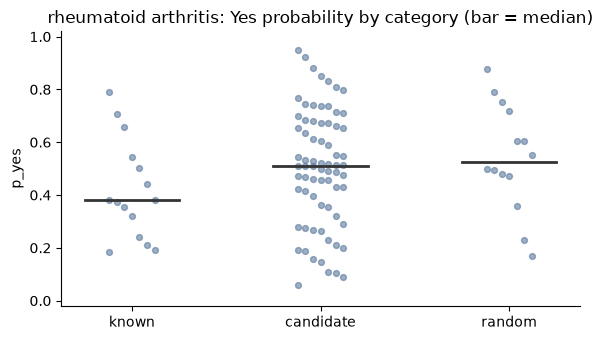

,symbol,gene_label,category,p_yes,yes_fraction,n_valid
0,CD40,CD40 (CD40 molecule),candidate,0.9475,1.0,5
1,MAPK14,MAPK14 (mitogen-activated protein kinase 14),candidate,0.9215,1.0,5
2,IL17RA,IL17RA (interleukin 17 receptor A),candidate,0.8810,1.0,5
3,NUDT1,NUDT1 (nudix hydrolase 1),random,0.8780,0.8,5
4,IKZF3,IKZF3 (IKAROS family zinc finger 3),candidate,0.8520,1.0,5
5,ETS1,"ETS1 (ETS proto-oncogene 1, transcription factor)",candidate,0.8305,1.0,5
6,REL,"REL (REL proto-oncogene, NF-kB subunit)",candidate,0.8110,0.6,5
7,CD28,CD28 (CD28 molecule),candidate,0.7965,1.0,5
8,IL6R,IL6R (interleukin 6 receptor),known,0.7915,0.6,5
9,CDC20B,CDC20B (cell division cycle 20B),random,0.7910,0.6,5


In [8]:
res = pd.read_csv(OUT_CSV)
res = res[res["disease"] == DISEASE].drop_duplicates("symbol", keep="last")
score_col = "p_yes" if MODE in ("logprob", "both") else "yes_fraction"
res = res.sort_values(score_col, ascending=False).reset_index(drop=True)
if USE_LLM is False: print("警告: モックの数値です。")
display(res.groupby("category")[[c for c in ("p_yes", "yes_fraction") if c in res.columns]].agg(["mean", "median", "count"]).round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
cats = [c for c in ("known", "candidate", "random") if c in set(res["category"])]
for k, cat in enumerate(cats):
    v = res.loc[res["category"] == cat, score_col].dropna()
    ax.scatter([k + (random.Random(cat).random() - 0.5) * 0.3 for _ in v] if False else [k] * len(v) + (pd.Series(range(len(v))) % 7 - 3) * 0.04, v, s=18, color="#5b7a9d", alpha=0.6)
    ax.plot([k - 0.25, k + 0.25], [v.median()] * 2, color="#333", linewidth=2)
ax.set_xticks(range(len(cats))); ax.set_xticklabels(cats); ax.set_ylim(-0.02, 1.02); ax.set_ylabel(score_col)
ax.set_title(f"{DISEASE}: Yes probability by category (bar = median)")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
res[["symbol", "gene_label", "category", score_col] + (["yes_fraction", "n_valid"] if "yes_fraction" in res.columns and score_col != "yes_fraction" else [])].head(20)

## 評価

### このセルがすること：正解遺伝子が上位に来るかを数字にする
1. **上位k中の正解数**（k = 10, 20）と、でたらめに選んだ場合の期待値（k × 正解の割合）。
2. **AUC**：正解 vs それ以外で、正解の方が高い確率を持つ割合（Mann-Whitney の U から計算）。0.5 がでたらめ、1.0 が完全。
3. **可能性 vs ランダムの AUC**：直接の報告が無い遺伝子をランダムより上に置けているか。

In [9]:
def auc(pos, neg):
    """AUC = P(正例のスコア > 負例のスコア)（同点は 0.5）。pos, neg はスコアのリスト。"""
    pos, neg = list(pos), list(neg)
    if not pos or not neg: return float("nan")
    wins = sum(1.0 if p > n else 0.5 if p == n else 0.0 for p in pos for n in neg)
    return wins / (len(pos) * len(neg))

if "label" in res.columns and res["label"].notna().any():
    n_known = int((res["category"] == "known").sum())
    rows = []
    for k in (10, 20):
        top = res.head(k)
        rows.append({"k": k, "known in top-k": int((top["category"] == "known").sum()),
                     "random expectation": round(k * n_known / len(res), 2)})
    display(pd.DataFrame(rows))
    s = res[score_col]
    print(f"AUC known vs others        : {auc(s[res['category']=='known'], s[res['category']!='known']):.3f}")
    if (res["category"] == "candidate").any():
        print(f"AUC candidate vs random    : {auc(s[res['category']=='candidate'], s[res['category']=='random']):.3f}")
        print(f"AUC known vs random        : {auc(s[res['category']=='known'], s[res['category']=='random']):.3f}")
    if "yes_fraction" in res.columns and "p_yes" in res.columns and res["yes_fraction"].notna().any():
        print(f"corr(p_yes, yes_fraction)  : {res['p_yes'].corr(res['yes_fraction']):.3f}  (サンプリングは確率読みの推定値)")
else:
    print("category / label 列が無いので、順位表のみ。上位:", res["symbol"].head(10).tolist())

,k,known in top-k,random expectation
0,10,1,1.5
1,20,2,3.0


AUC known vs others        : 0.364
AUC candidate vs random    : 0.448
AUC known vs random        : 0.324
corr(p_yes, yes_fraction)  : 0.735  (サンプリングは確率読みの推定値)


## 別の病気で使うには

設定セルの `DISEASE`、`DISEASE_INFO`（最大5個。症状 → 臓器・細胞・機能。分子名・原因遺伝子名は書かない）、`GENE_FILE` を変えるだけです。例（統合失調症）：

```python
DISEASE = "schizophrenia"
DISEASE_INFO = [
    "Hallucinations, delusions and disorganised thought (positive symptoms): linked to excessive neurotransmission in striatal circuits of the basal ganglia",
    "Loss of motivation, blunted emotion and social withdrawal (negative symptoms): related to reduced activity of prefrontal cortical circuits",
    "Deficits in working memory, attention and executive function: impaired excitatory synaptic signalling and inhibitory interneuron dysfunction in prefrontal cortex and hippocampus",
    "Onset in late adolescence: coincides with excessive elimination of synapses and disturbed development of cortical circuits",
    "Chronic relapsing course: persistent dysregulation of cortico-striato-thalamic loops",
]
GENE_FILE = os.path.join(ROOT, "data", "genes", "scz_set100.tsv")
```